# **Prerequisites**

In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Some prerequisit operations

! pip install git+https://github.com/gautamchitnis/cocoapi.git@cocodataset-master#subdirectory=PythonAPI

# Fixing the numpy float error
from packaging import version
import numpy as np
if version.parse(np.__version__) >= version.parse("1.24.0"):
    np.float = np.float32

! wget "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py"
! wget "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py"
! wget "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py"
! wget "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py"
! wget "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py"

# Installing the requirements
!pip install torch torchvision albumentations
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image


  Cloning https://github.com/gautamchitnis/cocoapi.git (to revision cocodataset-master) to /tmp/pip-req-build-sqouovq2
  Running command git clone --filter=blob:none --quiet https://github.com/gautamchitnis/cocoapi.git /tmp/pip-req-build-sqouovq2
  Running command git checkout -b cocodataset-master --track origin/cocodataset-master
  Switched to a new branch 'cocodataset-master'
  Branch 'cocodataset-master' set up to track remote branch 'cocodataset-master' from 'origin'.
  Resolved https://github.com/gautamchitnis/cocoapi.git to commit 20291f19c46a8d11935862bc9e449a1b72ec25ed
  Preparing metadata (setup.py) ... done
  Created wheel for pycocotools: filename=pycocotools-2.0-cp312-cp312-linux_x86_64.whl size=426712 sha256=e2830d96a1c16ba8708bf72ec6bad3bde3c442bd08faeae0502bf81e3704bb0a
  Stored in directory: /tmp/pip-ephem-wheel-cache-kikekv1u/wheels/ea/8c/fa/4f03267588f8d0f0b112be6e2a5170e31b2e836d271087b439
Successfully built pycocotools
  Attempting uninstall: pycocotools
    Found 

# **Data Loader**

In [ ]:
# Data loader and transformation class

import json
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import numpy as np
import utils


# Custom Transform Function
class CustomTransform:
    def __init__(self, size):
        self.size = size
        self.resize = T.Resize(size)
    def __call__(self, image, target):
        # Get the original dimensions
        w_orig, h_orig = image.shape[2], image.shape[1]
        # Resize image
        image = self.resize(image)
        # Get the new dimensions
        w_new, h_new = self.size
        # Calculate the scale factors
        scale_x = w_new / w_orig
        scale_y = h_new / h_orig
        # Resize bounding boxes
        boxes = target["boxes"]
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y
        target["boxes"] = boxes

        return image, target


# Custom Dataset Class
class CustomLUNA16DataSet(Dataset):
    def __init__(self, image_path, annotations, transforms=None):
        self.image_path = image_path
        self.annotations = annotations
        self.transforms = transforms

    def __getitem__(self, idx):
        # Load image path
        img_path = os.path.join(self.image_path, self.annotations[idx]['file_name'])
        # Open the image
        img = Image.open(img_path)
        # Convert image to numpy array
        image_array = np.array(img)
        # Normalize the image to range [0, 1]
        image_normalized = image_array / 4095.0  # Since 2^12 - 1 = 4095
        # Clip the normalized image to ensure values are in range [0, 1]
        image_normalized = np.clip(image_normalized, 0, 1)
        # Convert to float32 for PyTorch
        image_float = image_normalized.astype(np.float32)
        # Convert to PyTorch tensor
        image_tensor = torch.tensor(image_float)
        # Add channel dimension (since it's grayscale, we add one channel)
        image = image_tensor.unsqueeze(0)
        # Get bounding boxes and labels
        bbox = self.annotations[idx]['annotations'][0]['bbox']
        x, y, w, h = bbox
        # Add a % to width and height
        w = round(w * 1.2)
        h = round(h * 1.2)
        x = x - round((w * 0.1))
        y = y - round((h * 0.1))
        x1, y1, x2, y2 = x, y, x + w, y + h

        bbox = [x1, y1, x2, y2]
        boxes = torch.tensor([bbox], dtype=torch.float32)
        labels = torch.tensor([self.annotations[idx]['annotations'][0]['category_id']], dtype=torch.int64)
        # image_id = torch.tensor([idx])
        image_id = self.annotations[idx]['image_id']

        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((1,), dtype=torch.int64)

        target = {}
        target['file_name'] = self.annotations[idx]['file_name']
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        return image, target

    def __len__(self):
        return len(self.annotations)


In [ ]:
# Preparing Datasets

import json
import os
import random
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import numpy as np
import utils


train_image_dir = '/content/drive/MyDrive/LUNA16/Train'
with open('/content/drive/MyDrive/LUNA16/Train/LUNA16_nodule_train_annotations(with image_id).json', 'r') as f:
    train_annotations = json.load(f)

test_image_dir = '/content/drive/MyDrive/LUNA16/Test'
with open('/content/drive/MyDrive/LUNA16/Test/LUNA16_nodule_test_annotations(with image_id).json', 'r') as f:
    test_annotations = json.load(f)

# # Define the transformation
transform = CustomTransform(size=(224, 224))

# Create the dataset with the custom transform
train_dataset = CustomLUNA16DataSet(train_image_dir,
                                    train_annotations,
                                    transforms = transform
                                    )
test_dataset = CustomLUNA16DataSet(test_image_dir,
                                   test_annotations,
                                   )

def custom_collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images, dim=0)
    return images, targets

# Create data loaders
train_data_loader = DataLoader(train_dataset,
                               batch_size = 2,
                               shuffle=True,
                               num_workers = 2,
                               collate_fn = custom_collate_fn)
test_data_loader = DataLoader(test_dataset,
                              batch_size = 2,
                              shuffle = False,
                              num_workers = 2,
                              collate_fn = custom_collate_fn)


# **Visualization**

In [ ]:
# Visualizing the images with their bounding boxes

import matplotlib.pyplot as plt

def draw_bounding_boxes_on_slice(slice_img, annotations, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(slice_img, cmap= 'gray')
    ax = plt.gca()

    for ann in annotations:
        if 'bbox' in ann:
            bbox = ann['bbox']
            x1, y1, x2, y2 = bbox
            width = x2 - x1
            height = y2 - y1
            # Draw the bounding box
            rect = plt.Rectangle((bbox[0], bbox[1]), width, height, edgecolor='blue', facecolor='none')
            ax.add_patch(rect)

            # Add the class label text
            if 'category_id' in ann:
                class_text = f"class {ann['category_id']}"
                # Calculate the height of the bounding box
                bbox_height = bbox[3]
                # Determine a proportional font size
                font_size = max(6, min(12, bbox_height * 0.2))
                # Adjust the text position to the top-right corner outside the bounding box
                text_x = bbox[0] + (bbox[2] - bbox[0]) + 4  # Slightly to the right of the top-right corner
                text_y = bbox[1] - (bbox[1] - bbox[3]) - 12  # Slightly above the top-right corner
                # Draw the text with a semi-transparent background
                # ax.text(text_x, text_y, class_text, color='blue', fontsize=font_size, weight='bold',
                #         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    plt.axis('off')
    plt.show()

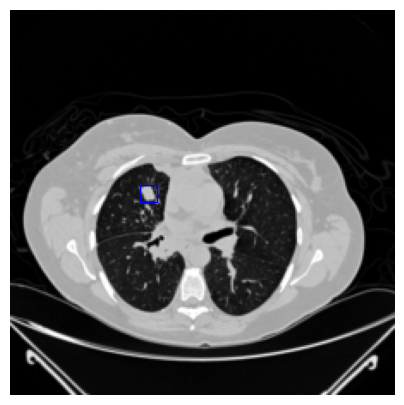

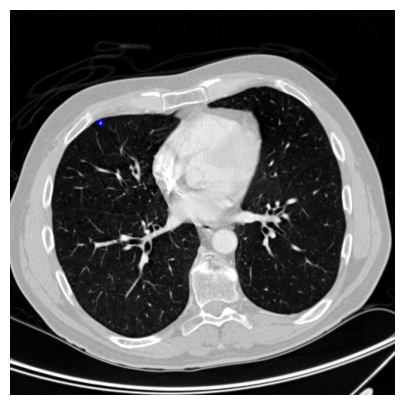

In [ ]:
images, targets = next(iter(train_data_loader))
# Load a sample image and its annotations
image, target= images[0], targets[0]
# Convert the image tensor to a numpy array
image_np = image.squeeze().numpy()  # Remove the channel dimension
# Draw bounding boxes on the image
draw_bounding_boxes_on_slice(image_np, [{'bbox': bbox.tolist(), 'category_id': label.item()} for bbox, label in zip(target['boxes'], target['labels'])])


images, targets = next(iter(test_data_loader))
# Load a sample image and its annotations
image, target= images[0], targets[0]
# Convert the image tensor to a numpy array
image_np = image.squeeze().numpy()  # Remove the channel dimension
# Draw bounding boxes on the image
draw_bounding_boxes_on_slice(image_np, [{'bbox': bbox.tolist(), 'category_id': label.item()} for bbox, label in zip(target['boxes'], target['labels'])])


# **Model Configuration**

In [ ]:
# Configuring the Feature Pyramid Network

import warnings
from typing import Callable, Dict, List, Optional, Union
from torch import nn, Tensor
from torchvision.ops import misc as misc_nn_ops
from torchvision.ops.feature_pyramid_network import ExtraFPNBlock, FeaturePyramidNetwork, LastLevelMaxPool
from torchvision import models
from torchvision.models import mobilenet, resnet
from torchvision.models._api import _get_enum_from_fn, WeightsEnum
from torchvision.models._utils import handle_legacy_interface, IntermediateLayerGetter


class BackboneWithFPN(nn.Module):
    def __init__(
        self,
        backbone: nn.Module,
        return_layers: Dict[str, str],
        in_channels_list: List[int],
        out_channels: int,
        extra_blocks: Optional[ExtraFPNBlock] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if extra_blocks is None:
            extra_blocks = LastLevelMaxPool()

        self.body = IntermediateLayerGetter(backbone, return_layers=return_layers)
        self.fpn = FeaturePyramidNetwork(
            in_channels_list=in_channels_list,
            out_channels=out_channels,
            extra_blocks=extra_blocks,
            norm_layer=norm_layer,
        )
        self.out_channels = out_channels

    def forward(self, x: Tensor) -> Dict[str, Tensor]:
        x = self.body(x)
        permuted_feature_maps = {str(i): torch.permute(x[k], (0, 3, 1, 2)) for i, k in enumerate(x)}
        x = self.fpn(permuted_feature_maps)
        return x


In [ ]:
# Object detection model configuration

import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torch.nn as nn
import torch
import torch.nn.functional as F


class SwinBackboneWithFPN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.swin_t(weights="DEFAULT").features
        # Modifying the first layer of the model to receive images with one channel
        first_conv_layer = self.backbone[0][0]
        new_first_conv_layer = nn.Conv2d(
            in_channels = 1,  # The number of input image channels
            out_channels = first_conv_layer.out_channels,
            kernel_size = first_conv_layer.kernel_size,
            stride = first_conv_layer.stride,
            padding = first_conv_layer.padding,
            bias = first_conv_layer.bias is not None        )
        # Copy the original weights, average them to adapt to the single channel input
        with torch.no_grad():
            new_first_conv_layer.weight = nn.Parameter(
                first_conv_layer.weight.mean(dim = 1, keepdim = True))
            if first_conv_layer.bias is not None:
                new_first_conv_layer.bias = nn.Parameter(first_conv_layer.bias)
        # Replace the original conv layer with the new one
        self.backbone[0][0] = new_first_conv_layer

        self.return_layers = {'1': '0', '3': '1', '5': '2', '7': '3'}
        self.in_channels_list = [96, 192, 384, 768]
        self.out_channels = 256
        self.fpn = BackboneWithFPN(self.backbone,
                                   self.return_layers,
                                   self.in_channels_list,
                                   self.out_channels)
    def forward(self, x):
        return self.fpn(x)

def get_our_model(num_classes):
    backbone = SwinBackboneWithFPN()
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),) * 5,
        aspect_ratios=((0.5, 1.0, 2.0),) * 5    )
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0', '1', '2', '3', '4'],
        output_size=7,
        sampling_ratio=2    )
    mean = [0.3092506481092485]
    std = [0.33650087260053957]
    model = FasterRCNN(
        backbone,
        num_classes = num_classes,
        rpn_anchor_generator = anchor_generator,
        box_roi_pool = roi_pooler,
        # min_size = 512,
        image_mean = mean,
        image_std = std
     )
    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


In [ ]:
# Object detection model configuration + cosine

import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torch.nn as nn
import torch
import torch.nn.functional as F

class CosineSimLinear(nn.Module):
    def __init__(self, in_features, out_features, scale=20.0):
        super().__init__()
        self.scale = scale
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        # x: [N, in_features] ROI-pooled features
        x_norm = F.normalize(x, p=2, dim=1)              # instance-level normalization
        w_norm = F.normalize(self.weight, p=2, dim=1)    # normalize class weights
        return self.scale * torch.matmul(x_norm, w_norm.t())

class CosineFastRCNNPredictor(nn.Module):
    def __init__(self, in_channels, num_classes, scale=20.0):
        super().__init__()
        self.cls_score = CosineSimLinear(in_channels, num_classes, scale=scale)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        if x.dim() == 4:
            x = torch.flatten(x, start_dim=1)
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas


class SwinBackboneWithFPN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.swin_t(weights="DEFAULT").features
        # Modifying the first layer of the model to receive images with one channel
        first_conv_layer = self.backbone[0][0]
        new_first_conv_layer = nn.Conv2d(
            in_channels = 1,  # The number of input image channels
            out_channels = first_conv_layer.out_channels,
            kernel_size = first_conv_layer.kernel_size,
            stride = first_conv_layer.stride,
            padding = first_conv_layer.padding,
            bias = first_conv_layer.bias is not None        )
        # Copy the original weights, average them to adapt to the single channel input
        with torch.no_grad():
            new_first_conv_layer.weight = nn.Parameter(
                first_conv_layer.weight.mean(dim = 1, keepdim = True))
            if first_conv_layer.bias is not None:
                new_first_conv_layer.bias = nn.Parameter(first_conv_layer.bias)
        # Replace the original conv layer with the new one
        self.backbone[0][0] = new_first_conv_layer

        self.return_layers = {'1': '0', '3': '1', '5': '2', '7': '3'}
        self.in_channels_list = [96, 192, 384, 768]
        self.out_channels = 256
        self.fpn = BackboneWithFPN(self.backbone,
                                   self.return_layers,
                                   self.in_channels_list,
                                   self.out_channels)
    def forward(self, x):
        return self.fpn(x)

def get_our_model_cosine(num_classes):
    backbone = SwinBackboneWithFPN()
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),) * 5,
        aspect_ratios=((0.5, 1.0, 2.0),) * 5    )
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0', '1', '2', '3', '4'],
        output_size=7,
        sampling_ratio=2)
    mean = [0.3092506481092485]
    std = [0.33650087260053957]
    model = FasterRCNN(
        backbone,
        num_classes = num_classes,
        rpn_anchor_generator = anchor_generator,
        box_roi_pool = roi_pooler,
        # min_size = 512,
        image_mean = mean,
        image_std = std
     )
    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = CosineFastRCNNPredictor(in_features, num_classes)
    return model


In [ ]:
# Other models for comparison

# ******************************************************************************
# resnet101 ********************************************************************
# ******************************************************************************

def get_model_resnet50(num_classes):
    backbone = torchvision.models.resnet101(weights="DEFAULT")
    backbone_features = nn.Sequential(*list(backbone.children())[:-1])
    backbone_features.out_channels = 2048
    model = FasterRCNN(
        backbone=backbone_features,
        num_classes=num_classes,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# ******************************************************************************
# ResNet50 + fpn ***************************************************************
# ******************************************************************************

from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
def get_model_custom_resnet50fpn(num_classes):
    # Load a pre-trained model for classification and return only the features
    backbone = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT").backbone
    backbone.out_channels = 256
    anchor_generator = AnchorGenerator(

        sizes = ((32, 64, 128, 256, 512),) * 5,
        aspect_ratios=(0.5, 1.0, 2.0),  # Same aspect ratios for all levels
)
    # Define the region of interest (RoI) pooling
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0','1','2','3','pool'],
        output_size=7,
        sampling_ratio=2
    )
    # Create the model
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# ******************************************************************************
# Swin-T + fpn (with 3 channel input)*******************************************
# ******************************************************************************

import numpy as np
class SwinBackboneWithFPN3channel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.swin_t(weights='DEFAULT').features
        self.return_layers = {'1': '0', '3': '1', '5': '2', '7': '3'}
        self.in_channels_list = [96, 192, 384, 768]
        self.out_channels = 256
        self.fpn = BackboneWithFPN(self.backbone,
                                   self.return_layers,
                                   self.in_channels_list,
                                   self.out_channels)
    def forward(self, x):
        return self.fpn(x)

def get_model_swin_t_fpn(num_classes):
    backbone = SwinBackboneWithFPN3channel()
    anchor_generator = AnchorGenerator(
        sizes = ((32, 64, 128, 256, 512),) * 5,
        aspect_ratios = ((0.5, 1.0, 2.0),) * 5    )
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names = ['0', '1', '2', '3', '4'],
        output_size = 7,
        sampling_ratio = 2)
    model = FasterRCNN(
        backbone,
        num_classes = num_classes,
        rpn_anchor_generator = anchor_generator,
        box_roi_pool=roi_pooler)

    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model



# ******************************************************************************
# Swin Transformer + cosine classification *************************************
# ******************************************************************************

class CosineSimLinear(nn.Module):
    def __init__(self, in_features, out_features, scale=20.0):
        super().__init__()
        self.scale = scale
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        # x: [N, in_features] ROI-pooled features
        x_norm = F.normalize(x, p=2, dim=1)              # instance-level normalization
        w_norm = F.normalize(self.weight, p=2, dim=1)    # normalize class weights
        return self.scale * torch.matmul(x_norm, w_norm.t())


class CosineFastRCNNPredictor(nn.Module):
    def __init__(self, in_channels, num_classes, scale=20.0, cls_agnostic_bbox_reg=False):
        super().__init__()
        self.cls_agnostic_bbox_reg = cls_agnostic_bbox_reg
        self.num_classes = num_classes
        self.cls_score = CosineSimLinear(in_channels, num_classes, scale=scale)

        if cls_agnostic_bbox_reg:
            out_dim = 4
        else:
            out_dim = num_classes * 4
        self.bbox_pred = nn.Linear(in_channels, out_dim)

    def forward(self, x):
        if x.dim() == 4:
            x = torch.flatten(x, start_dim=1)
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)

        if self.cls_agnostic_bbox_reg:
            # We are predicting 4 box parameters per proposal,
            # so we need to repeat them for each class to match the expected shape.
            bbox_deltas = bbox_deltas[:, None].expand(-1, self.num_classes, -1).reshape(-1, self.num_classes * 4)

        return scores, bbox_deltas


class SwinTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.swin_t(weights="DEFAULT").features
        self.out_channels = 768
    def forward(self, x):
      return torch.permute(self.backbone(x), (0, 3, 1, 2))

def get_model_swin_t(num_classes):
  anchor_generator = AnchorGenerator(
      sizes = ((32, 64, 128, 256, 512),),
      aspect_ratios = ((0.5, 1.0, 2.0),))
  roi_pooler = torchvision.ops.MultiScaleRoIAlign(
      featmap_names = ['0'],
      output_size = 7,
      sampling_ratio = 2)
  swin_backbone = SwinTransformer()
  model = FasterRCNN(
      swin_backbone,
      num_classes = 5,
      rpn_anchor_generator = anchor_generator,
      box_roi_pool = roi_pooler,
      # min_size = 300,
      )

  in_features = model.roi_heads.box_predictor.cls_score.in_features
  box_predictor = CosineFastRCNNPredictor(
                in_features, num_classes, scale=20.0, cls_agnostic_bbox_reg=True)
  model.roi_heads.box_predictor = box_predictor

  return model



# ******************************************************************************
# Swin Transformer (base model) ************************************************
# ******************************************************************************

class SwinTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.swin_t(weights="DEFAULT").features
        self.out_channels = 768
    def forward(self, x):
      return torch.permute(self.backbone(x), (0, 3, 1, 2))

def get_model_swin_t(num_classes):
  anchor_generator = AnchorGenerator(
      sizes = ((32, 64, 128, 256, 512),),
      aspect_ratios = ((0.5, 1.0, 2.0),))
  roi_pooler = torchvision.ops.MultiScaleRoIAlign(
      featmap_names = ['0'],
      output_size = 7,
      sampling_ratio = 2)
  swin_backbone = SwinTransformer()
  model = FasterRCNN(
      swin_backbone,
      num_classes = 5,
      rpn_anchor_generator = anchor_generator,
      box_roi_pool = roi_pooler,
      )

  in_features = model.roi_heads.box_predictor.cls_score.in_features
  model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

  return model

# ******************************************************************************
# Swin-T + fpn (with 3 channel input) + Cosine similarity **********************
# ******************************************************************************

import torch
import torch.nn as nn
import torch.nn.functional as F

class CosineSimLinear(nn.Module):
    def __init__(self, in_features, out_features, scale=20.0):
        super().__init__()
        self.scale = scale
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x):
        # x: [N, in_features] ROI-pooled features
        x_norm = F.normalize(x, p=2, dim=1)              # instance-level normalization
        w_norm = F.normalize(self.weight, p=2, dim=1)    # normalize class weights
        return self.scale * torch.matmul(x_norm, w_norm.t())


from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

class CosineFastRCNNPredictor(nn.Module):
    def __init__(self, in_channels, num_classes, scale=20.0):
        super().__init__()
        self.cls_score = CosineSimLinear(in_channels, num_classes, scale=scale)
        self.bbox_pred = nn.Linear(in_channels, num_classes * 4)

    def forward(self, x):
        if x.dim() == 4:
            x = torch.flatten(x, start_dim=1)
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas


import numpy as np
class SwinBackboneWithFPN3channel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.swin_t(weights='DEFAULT').features
        self.return_layers = {'1': '0', '3': '1', '5': '2', '7': '3'}
        self.in_channels_list = [96, 192, 384, 768]
        self.out_channels = 256
        self.fpn = BackboneWithFPN(self.backbone,
                                   self.return_layers,
                                   self.in_channels_list,
                                   self.out_channels)
    def forward(self, x):
        return self.fpn(x)

def get_model_swin_t_fpn_cosine(num_classes):
    backbone = SwinBackboneWithFPN3channel()
    anchor_generator = AnchorGenerator(
        sizes = ((32, 64, 128, 256, 512),) * 5,
        aspect_ratios = ((0.5, 1.0, 2.0),) * 5    )
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names = ['0', '1', '2', '3', '4'],
        output_size = 7,
        sampling_ratio = 2)
    model = FasterRCNN(
        backbone,
        num_classes = num_classes,
        rpn_anchor_generator = anchor_generator,
        box_roi_pool=roi_pooler)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    box_predictor = CosineFastRCNNPredictor(in_features, num_classes, scale=20.0)
    model.roi_heads.box_predictor = box_predictor
    return model


# ******************************************************************************
# VGG16 ************************************************************************
# ******************************************************************************

import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_model_vgg16(num_classes):
    # Load a pre-trained VGG-16 model
    backbone = torchvision.models.vgg16(weights='DEFAULT').features

    # VGG-16 features output channels is 512
    backbone.out_channels = 512

    # Generate anchors with sizes and aspect ratios
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # RoIAlign with feature map names, output size and sampling ratio
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    # Initialize the Faster R-CNN model
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    # Replace the pre-trained head with a new one for our number of classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model



# ******************************************************************************
# ResNet50 *********************************************************************
# ******************************************************************************


def get_model_custom_resnet50(num_classes):

    # Load a pre-trained model for classification and return only the features
    model = torchvision.models.resnet50(weights="DEFAULT")
    backbone = nn.Sequential(*list(model.children())[:-1])
    backbone.out_channels = 2048

    # Adjust anchor generator for the FPN
    anchor_generator = AnchorGenerator(
        sizes = ((32, 64, 128, 256, 512),),
        aspect_ratios = (0.5, 1.0, 2.0),

    )

    # Define the region of interest (RoI) pooling
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    # Create the model
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# **Training & Evaluation Procedure**

In [ ]:
# COCO evaluation Function

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np
import torch

def get_coco_api_from_dataset(dataset):
    coco = COCO()
    coco.dataset = {
        'images': [],
        'annotations': [],
        'categories': []
    }
    ann_id = 0  # Initialize annotation ID
    for i in range(len(dataset)):
        img, target = dataset[i]
        # image_id = int(target["image_id"])
        image_id = target["image_id"]
        coco.dataset['images'].append({
            'id': image_id
        })
        boxes = target["boxes"]
        labels = target["labels"]
        areas = target["area"]
        iscrowd = target["iscrowd"]
        for box, label, area, crowd in zip(boxes, labels, areas, iscrowd):
            coco.dataset['annotations'].append({
                'id': ann_id,  # Add unique ID for each annotation
                'image_id': image_id,
                'bbox': box.tolist(),
                'category_id': int(label),
                'area': float(area),
                'iscrowd': int(crowd)
            })
            ann_id += 1  # Increment annotation ID
    coco.dataset['categories'] = [{'id': i, 'name': str(i)} for i in range(2)]  # Assuming 2 classes
    coco.createIndex()
    return coco

def evaluate_model(model, data_loader, device, small, medium, large):
    model.eval()
    coco = get_coco_api_from_dataset(data_loader.dataset)
    coco_results = []
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)
            for target, output in zip(targets, outputs):
                # image_id = int(target["image_id"])
                image_id = target["image_id"]
                boxes = output["boxes"].cpu()
                scores = output["scores"].cpu()
                labels = output["labels"].cpu()
                for box, score, label in zip(boxes, scores, labels):
                    coco_results.append({
                        'image_id': image_id,
                        'category_id': int(label),
                        'bbox': box.tolist(),
                        'score': float(score)
                    })

    coco_dt = coco.loadRes(coco_results)
    coco_eval = COCOeval(coco, coco_dt, 'bbox')

    # Set maxDets and areaRng before evaluating
    coco_eval.params.maxDets = [1, 10, 100]
    coco_eval.params.areaRng = [
        [0, large],                     # All sizes
        [0, small],                     # Small nodules
        [small + 1, medium],            # Medium nodules
        [medium + 1, large]             # Large nodules
    ]

    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    # Extract and print Precision and Recall for specific IoU thresholds 0.5, 0.75, 0.95
    precisions = coco_eval.eval['precision']
    recalls = coco_eval.eval['recall']
    iou_thresh = [0.5, 0.75, 0.95]
    max_dets = [1, 2, 3]

    # Indices for area ranges: all, small, medium, large
    area_indices = {
        'all': 0,
        'small': 1,
        'medium': 2,
        'large': 3
    }

    for area_name, area_idx in area_indices.items():
        print(f"\nPrecision and Recall for area: {area_name.capitalize()}")
        for iou_idx, iou in enumerate(iou_thresh):
            for det_idx, det in enumerate(max_dets):
                precision = precisions[iou_idx, :, :, area_idx, det_idx]
                recall = recalls[iou_idx, :, area_idx, det_idx]

                if precision.size > 0:
                    ap = np.mean(precision[precision > -1])
                else:
                    ap = -1

                if recall.size > 0:
                    ar = np.mean(recall[recall > -1])
                else:
                    ar = -1

                print(f'@[ IoU={iou:.2f} | maxDets={det} ] -> AP: {ap:.3f}, AR: {ar:.3f}')

    # Extracting mAP and AR over all IoU thresholds 0.5:0.95 for maxDets 1, 10, 100 and all areas
    print("\nDetailed results over all IoU thresholds [0.5:0.95] for each condition:")

    for area_name, area_idx in area_indices.items():
        print(f"\nArea: {area_name.capitalize()}")
        for det_idx, det in enumerate(max_dets):
            # Precision
            precision = precisions[:, :, :, area_idx, det_idx]
            if precision.size > 0:
                ap = np.mean(precision[precision > -1])
            else:
                ap = -1
            print(f'Precision @[ IoU=0.5:0.95 | maxDets={det} ] -> AP: {ap:.3f}')

            # Recall
            recall = recalls[:, :, area_idx, det_idx]
            if recall.size > 0:
                ar = np.mean(recall[recall > -1])
            else:
                ar = -1
            print(f'Recall @[ IoU=0.5:0.95 | maxDets={det} ] -> AR: {ar:.3f}')

    return coco_eval.stats

# Objects' area percentiles
percentile_small = 57.0
percentile_medium = 121.0
percentile_large = 961.0


In [ ]:
# Train_one_Epoch function

import math
import sys
import time
import torch
import torchvision.models.detection.mask_rcnn
import utils
from coco_eval import CocoEvaluator
from coco_utils import get_coco_api_from_dataset

def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq, scaler=None):
    model.train()
    metric_logger = utils.MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", utils.SmoothedValue(window_size=1, fmt="{value:.6f}"))
    header = f"Epoch: [{epoch}]"
    lr_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        lr_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )
    for images, targets in metric_logger.log_every(data_loader, print_freq, header):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]
        with torch.cuda.amp.autocast(enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        # reduce losses over all GPUs for logging purposes
        loss_dict_reduced = utils.reduce_dict(loss_dict)
        losses_reduced = sum(loss for loss in loss_dict_reduced.values())
        loss_value = losses_reduced.item()
        if not math.isfinite(loss_value):
            sys.exit(1)
        optimizer.zero_grad()
        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            optimizer.step()
        if lr_scheduler is not None:
            lr_scheduler.step()
        # Ensure there is no conflict with 'loss' key
        metric_logger.update(**{k: v for k, v in loss_dict_reduced.items() if k != 'loss'})
        metric_logger.update(loss=losses_reduced)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])
    return metric_logger



In [ ]:
# Training pipeline

from engine import _get_iou_types, evaluate
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# get the model using our helper function Class+1
model = get_our_model_cosine(2) # +1 class for the background
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.001,
    momentum=0.9,
    weight_decay=0.0005)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=8,
    gamma=0.1)

num_epochs = 3

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_data_loader, device, epoch, print_freq = 35)
    lr_scheduler.step()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    evaluate_model(model, test_data_loader, device, percentile_small, percentile_medium, percentile_large)



/tmp/ipython-input-69433457.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [  0/470]  eta: 0:06:16  lr: 0.000003  loss_classifier: 1.5837 (1.5837)  loss_box_reg: 0.0016 (0.0016)  loss_objectness: 0.7503 (0.7503)  loss_rpn_box_reg: 0.4773 (0.4773)  loss: 2.8129 (2.8129)  time: 0.8003  data: 0.1500  max mem: 5218
Epoch: [0]  [ 35/470]  eta: 0:04:39  lr: 0.000078  loss_classifier: 0.0278 (0.3887)  loss_box_reg: 0.0023 (0.0025)  loss_objectness: 0.7016 (0.7187)  loss_rpn_box_reg: 0.1267 (0.2168)  loss: 0.8742 (1.3267)  time: 0.6508  data: 0.0050  max mem: 5397
Epoch: [0]  [ 70/470]  eta: 0:04:13  lr: 0.000152  loss_classifier: 0.0167 (0.2060)  loss_box_reg: 0.0017 (0.0025)  loss_objectness: 0.4954 (0.6345)  loss_rpn_box_reg: 0.1061 (0.1685)  loss: 0.6073 (1.0116)  time: 0.6173  data: 0.0049  max mem: 5397
Epoch: [0]  [105/470]  eta: 0:03:47  lr: 0.000227  loss_classifier: 0.0168 (0.1442)  loss_box_reg: 0.0012 (0.0026)  loss_objectness: 0.2890 (0.5307)  loss_rpn_box_reg: 0.0518 (0.1512)  loss: 0.3799 (0.8287)  time: 0.6000  data: 0.0049  max mem: 5398


In [ ]:
# performing one detection to get timing with grayscale TIFF image

import torch
from torchvision import transforms
from PIL import Image
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

# path to your grayscale .tiff image
image_path = "/content/drive/MyDrive/LUNA16/Test/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860_slice_117.tiff"

# open as grayscale
img = Image.open(image_path).convert("L")  # "L" = 8-bit pixels, black and white

# if your model expects 1-channel input:
transform = transforms.Compose([
    transforms.ToTensor(),  # will give shape [1, H, W] for grayscale
])

img_tensor = transform(img).unsqueeze(0).to(device)  # add batch dimension, shape [1,1,H,W]

with torch.no_grad():
    start_time = time.time()
    outputs = model(img_tensor)
    end_time = time.time()

inference_time = end_time - start_time
print(f"Inference Time: {inference_time:.4f} seconds")

Inference Time: 0.1556 seconds
